In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

laliga = pd.read_csv('./drive/MyDrive/laliga.csv')
laliga.head()

,Team,Position,Shirt number,Name,Minutes played,Games played,Percentage of games played,Full games played,Percentage of full games played,Games started,...,Corners,Tackles.1,Duels,Man-to-man duels,Aerial duels,Passes,Short passes,Long passes,Through balls,Goals scored per attempt
0,Athletic Club,Goalkeeper,NaN,Hodei Oleaga,0.000,0,"0,0%",0,"0,0%",0,...,0,0,0,0,0,0.0,0.0,0,0,0
1,Athletic Club,Goalkeeper,1.0,A. Remiro,0.000,0,"0,0%",0,"0,0%",0,...,0,0,0,0,0,0.0,0.0,0,0,0
2,Athletic Club,Goalkeeper,13.0,Herrerín,2.790,31,"82,0%",31,"82,0%",31,...,0,0,25,6,19,887.0,128.0,759,1,0
3,Athletic Club,Goalkeeper,25.0,Unai Simón,630.000,7,"18,0%",7,"18,0%",7,...,0,0,3,2,1,155.0,49.0,106,0,0
4,Athletic Club,Defender,3.0,Núñez,1.063,12,"32,0%",11,"29,0%",11,...,0,15,107,38,69,536.0,457.0,78,1,0


In [21]:
laligaGoal = laliga[laliga['Goals scored'] >= 1]
X = np.array(laligaGoal['Shots'])
y = np.array(laligaGoal['Goals scored'])
xx = X[:, np.newaxis]
yy = y[:, np.newaxis]
xx_train = xx[:-75]
xx_test = xx[-75:]
yy_train = yy[:-75]
yy_test = yy[-75:]
reg = LinearRegression().fit(xx_train, yy_train)
print(f"R-squared score on training data: {reg.score(xx_train, yy_train)}")
yy_pred = reg.predict(xx_test)
print(f"Mean squared error on test data: {mean_squared_error(yy_test, yy_pred)}")

R-squared score on training data: 0.7649617284589343
Mean squared error on test data: 6.136379603608137


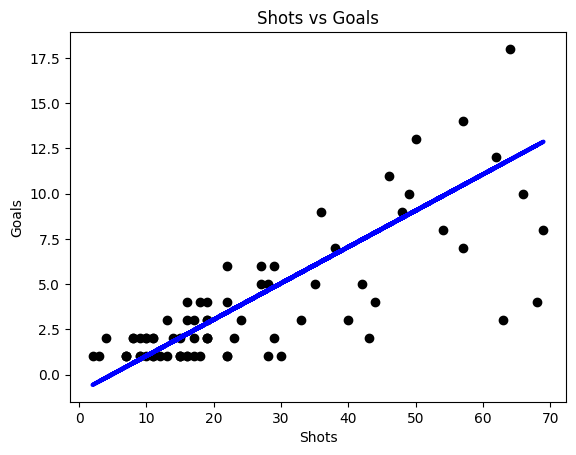

In [22]:
plt.scatter(xx_test, yy_test, color='black')
plt.plot(xx_test, yy_pred, color='blue', linewidth=3)
plt.title('Shots vs Goals')
plt.xlabel('Shots')
plt.ylabel('Goals')
plt.xticks()
plt.yticks()
plt.show()

In [23]:
ex = np.array([[75], [45], [24], [102]])
ex_goal = np.array([[10], [5], [6], [17]])
ex_pred = reg.predict(ex)
print(ex_pred)

[[14.07724635]
 [ 8.05615629]
 [ 3.84139324]
 [19.49622741]]


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

laliga = pd.read_csv('./drive/MyDrive/laliga.csv')
laliga['Position'] = laliga['Position'].map({'Goalkeeper':0, 'Defender':1, 'Midfielder':2, 'Forward':3})
laliga['Minutes played'] = laliga['Minutes played'].fillna(0)
laliga['Games played'] = laliga['Games played'].fillna(0)
laliga['Goals scored'] = laliga['Goals scored'].fillna(0)
laliga['Shots'] = laliga['Shots'].fillna(0)
laliga['Shots on target'] = laliga['Shots on target'].fillna(0)
laliga['Assists'] = laliga['Assists'].fillna(0)
laliga['Passes'] = laliga['Passes'].fillna(0)

feature = laliga[['Position', 'Minutes played', 'Games played', 'Shots', 'Shots on target', 'Assists', 'Passes']]
target = laliga['Goals scored']

In [28]:
feature_train, feature_test, target_train, target_test = train_test_split(feature, target, test_size = 0.3, random_state = 10)
reg = LinearRegression().fit(feature_train, target_train)
print(f"R-squared score on training data: {reg.score(feature_train, target_train)}")
target_pred = reg.predict(feature_test)
print(f"Mean squared error on test data: {mean_squared_error(target_test, target_pred)}")

R-squared score on training data: 0.8803334135969585
Mean squared error on test data: 1.9774277999843268


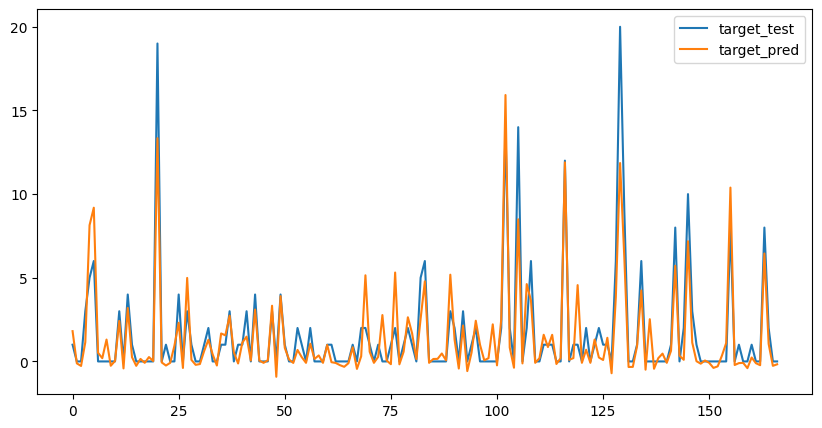

In [29]:
plt.figure(figsize=(10,5))
plt.plot(target_test.to_numpy(), label = 'target_test')
plt.plot(target_pred, label = 'target_pred')
plt.legend(loc=0)

In [32]:
Rakitic = [3, 2000, 24, 73, 34, 5, 829]
Leekangin = [3, 500, 8, 45, 19, 2, 356]
Ramos = [2, 1200, 15, 24, 3, 3, 644]
Benzema = [4, 2500, 33, 102, 52, 6, 1393]
reg.predict(np.array([Rakitic, Leekangin, Ramos, Benzema]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([11.06215186,  6.15277409,  0.03760206, 17.33869698])